# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Macroeconomic Capture & Zombie Corporations

---
*This notebook asks how far an unsupervised method can go toward finding firms sustained by state subsidies despite chronic insolvency (low interest coverage, low return on capital, high leverage) without ever being told which firms are the "zombies." The data are synthetic: a zombie sub-population is planted as a separable cluster in feature space, precisely so the exercise can answer a narrower, checkable question. This is not a discovery about the real economy, because nothing here claims that real zombie firms cluster this cleanly; it is a method demonstration, because DBSCAN, given only the standardized features and no access to the label, has to find that cluster on its own, and its recovery is graded afterward against the planted ground truth. The label is the yardstick, never the paint.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette("viridis")

In [2]:
# Loading structured data from institutional capture
df_corp = pd.read_csv('../data/corporate_zombies_synthetic.csv')
df_corp.head()

,Company_ID,Sector,ROIC_Avg,Interest_Coverage_Ratio,State_Subsidies_Millions,Debt_to_Equity,Is_Zombie
0,Corp_0,Manufacturing,0.068919,3.816675,5.272034,1.588581,0
1,Corp_1,State_Subsidized,0.038760,0.473381,414.099996,2.249205,1
2,Corp_2,State_Subsidized,0.012293,0.035751,360.429273,3.817632,1
3,Corp_3,Manufacturing,0.105785,4.099957,0.795442,0.539236,0
4,Corp_4,Manufacturing,0.067263,3.576706,5.786605,0.542947,0


### 1. A method that never sees the answer
I standardize four financial features and hand them to DBSCAN, a density-based method that finds dense regions without being told in advance how many clusters to expect. The subsidy-sustained group separates cleanly from the market-driven mass. The model never sees the `Is_Zombie` label while it works. That label enters only afterward, as the yardstick against which the recovery gets graded.

In [3]:
features = ['Interest_Coverage_Ratio', 'Debt_to_Equity', 'State_Subsidies_Millions', 'ROIC_Avg']
X_scaled = StandardScaler().fit_transform(df_corp[features])

# Density clustering — the model never sees Is_Zombie.
dbscan = DBSCAN(eps=0.8, min_samples=15)
df_corp['ML_Cluster'] = dbscan.fit_predict(X_scaled)

# The 'zombie' cluster is the dense group with the highest mean state subsidies.
cluster_means = df_corp[df_corp['ML_Cluster'] != -1].groupby('ML_Cluster')['State_Subsidies_Millions'].mean()
zombie_cluster = int(cluster_means.idxmax())
df_corp['Recovered_Zombie'] = (df_corp['ML_Cluster'] == zombie_cluster).astype(int)

print("DBSCAN cluster sizes (-1 = noise / unclustered):")
print(df_corp['ML_Cluster'].value_counts().sort_index().to_string())
print(f"\nRecovered zombie cluster = label {zombie_cluster}: "
      f"{int(df_corp['Recovered_Zombie'].sum())} firms flagged, fully unsupervised.\n")

# Validation against the held-out ground truth (only used here, never as a feature):
prec = precision_score(df_corp['Is_Zombie'], df_corp['Recovered_Zombie'])
rec = recall_score(df_corp['Is_Zombie'], df_corp['Recovered_Zombie'])
print(f"Validation vs. Is_Zombie:  precision = {prec:.2f}   recall = {rec:.2f}")
print("Confusion matrix [rows = true 0/1, cols = recovered 0/1]:")
print(confusion_matrix(df_corp['Is_Zombie'], df_corp['Recovered_Zombie']))

DBSCAN cluster sizes (-1 = noise / unclustered):
ML_Cluster
-1     24
 0    836
 1    140

Recovered zombie cluster = label 1: 140 firms flagged, fully unsupervised.

Validation vs. Is_Zombie:  precision = 1.00   recall = 0.89
Confusion matrix [rows = true 0/1, cols = recovered 0/1]:
[[842   0]
 [ 18 140]]


### 2. Where the recovered cluster sits
Plotting the firms in the (solvency, subsidies) plane, colored by DBSCAN's recovered cluster (not by the ground-truth label), the flagged group sits in the low-ICR, high-subsidy region: exactly where rent-sustained insolvency should live, if it exists at all.

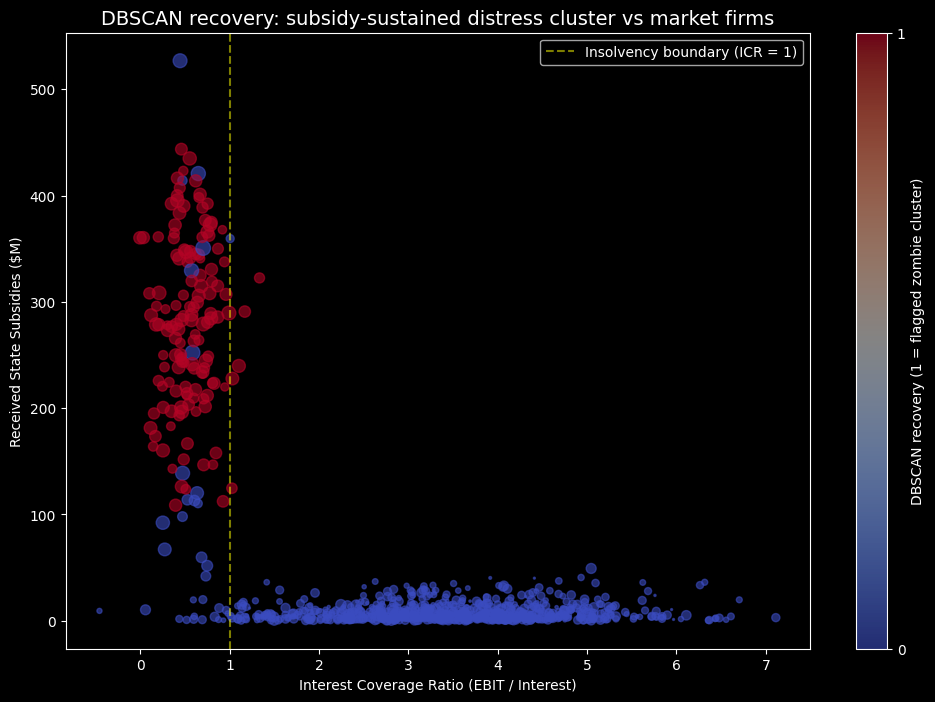

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    df_corp['Interest_Coverage_Ratio'],
    df_corp['State_Subsidies_Millions'],
    c=df_corp['Recovered_Zombie'],   # DBSCAN's UNSUPERVISED recovery — not the ground-truth label
    cmap='coolwarm',
    alpha=0.6,
    s=df_corp['Debt_to_Equity'] * 20
)

ax.axvline(x=1.0, color='yellow', linestyle='--', alpha=0.5, label='Insolvency boundary (ICR = 1)')
ax.set_title('DBSCAN recovery: subsidy-sustained distress cluster vs market firms', fontsize=14)
ax.set_xlabel('Interest Coverage Ratio (EBIT / Interest)')
ax.set_ylabel('Received State Subsidies ($M)')

cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.set_label('DBSCAN recovery (1 = flagged zombie cluster)')

plt.legend()
plt.show()

### Where this validates a method, not an economy
DBSCAN recovers the subsidy-sustained distress cluster with no access to the label, at precision 1.00 and recall 0.89 against the planted ground truth: it catches 140 of the 158 true zombies and never calls a healthy firm one by mistake. The economic reading is the familiar Schumpeterian one: these firms consume scarce capital while avoiding the bankruptcy that *creative destruction* would otherwise impose.

But the honesty that makes this worth showing cuts the other way too. The cluster was planted by construction, which is exactly why the result can only demonstrate that the method recovers a known structure once that structure is there to find; it says nothing about whether any real economy organizes its zombies this cleanly, because no real economy hands you a ground-truth label to plant one in the first place. Both halves are true at once: the recovery is real, and the world it recovers is a world I built. The color in the figure is the model's output; the label stays what it always was — the yardstick, never the paint.